# Homework 3 Solutions

1. Download daily price data for QQQ, TLT, GLD, RWO from yahoo finance since 2016-01-01. Using the adjusted close price data, compute daily returns. This should be a DataFrame with index=date, columns=ticker and values=daily returns.

In [1]:
import yfinance as yf

In [13]:
univ = ['QQQ','TLT','GLD','RWO']
px = yf.download(univ, start="2016-01-01")

[*********************100%***********************]  4 of 4 completed


In [15]:
import numpy as np
import pandas as pd
import math
px = pd.read_pickle('homework3_data.pkl')

In [16]:
adj_close = px['Close']
ret = adj_close / adj_close.shift() - 1

2. Compute the signal. Complete the compute_momentum function which computes a simple momentum signal. The function takes in a DataFrame with index = date, columns=ticker and values containing daily returns. It returns a new DataFrame with index = date, columns=ticker and values containing the momentum signal for the ticker on that day. The momentum signal for each ticker is defined as the annualized sharpe ratio of the past 252 days.

In [17]:
import math

def compute_momentum(ret):
    momentum = ret.rolling(252).mean()/ret.rolling(252).std()*math.sqrt(252)
    return momentum

momentum = compute_momentum(ret)
momentum

Ticker,GLD,QQQ,RWO,TLT
Date,,,,
2016-01-04,NaN,NaN,NaN,NaN
2016-01-05,NaN,NaN,NaN,NaN
2016-01-06,NaN,NaN,NaN,NaN
2016-01-07,NaN,NaN,NaN,NaN
2016-01-08,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-02-25,2.289326,0.868503,1.022794,0.443817
2026-02-26,2.377883,0.870907,1.020676,0.331614
2026-02-27,2.421099,0.846735,1.028627,0.333230


3. Create a portfolio. Complete the function compute_portfolio. This function takes as input the DataFrame "momentum" from above. It returns a new DataFrame "portfolio" which has the same index/columns and has as values portfolio weights. The weights are computed as follows. On each date, equal-weight long the tickers with a momentum signal above 1.

In [18]:
def compute_portfolio(momentum):
    portfolio = (momentum > 1)*1
    portfolio = portfolio.div(portfolio.abs().sum(1),0)
    return portfolio

portfolio = compute_portfolio(momentum)

/tmp/ipykernel_14064/1188758505.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  portfolio = portfolio.div(portfolio.abs().sum(1),0)


4. Portfolio returns. Using the "portfolio" returned in part(3) and the returns generated in part(1), compute the returns to the simple momentum strategy. 
- What is the annualized sharpe ratio of the strategy? 
- How about the annualized sharpe ratio within each year? 
- How correlated is the strategy with the underlying tickers?
- Plot the cumulative sum of the returns through time

In [19]:
strat_ret = (portfolio.shift()*ret).sum(1)
# minor, but should start returns when signal starts
strat_ret = strat_ret.loc[momentum.dropna().index[0]:] 

/tmp/ipykernel_14064/2915867735.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  strat_ret = (portfolio.shift()*ret).sum(1)


In [20]:
# sharpe
strat_ret.mean()/strat_ret.std()*math.sqrt(252)

np.float64(1.2696888996843156)

In [24]:
# sharpe within each year
import numpy as np 

sharpe = lambda x: x.mean()/x.std()*math.sqrt(252) 
strat_ret.groupby([x.year for x in strat_ret.index]).apply(sharpe)

2017    2.670449
2018   -0.024997
2019    1.015501
2020    1.528309
2021    1.411042
2022   -0.737297
2023    1.171872
2024    1.802067
2025    2.553750
2026    1.875198
dtype: float64

In [25]:
# correlation
ret.corrwith(strat_ret)

Ticker
GLD    0.531542
QQQ    0.389889
RWO    0.225826
TLT    0.168025
dtype: float64

<Axes: xlabel='Date'>

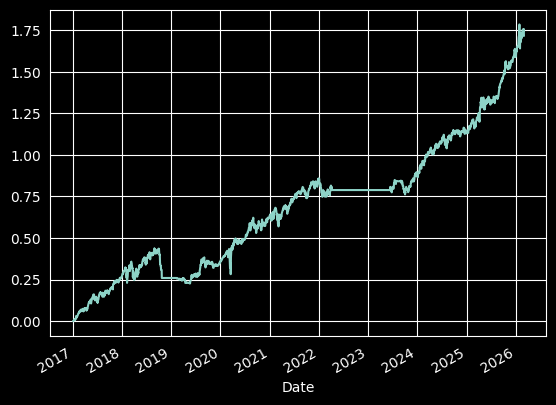

In [26]:
# cumulative returns
strat_ret.cumsum().plot()